## Data Profiling

In [1]:
import pandas as pd
import os 
import seaborn as sns 
import matplotlib.pyplot as plt

data = pd.read_parquet("../data/bronze/clean_dataset.parquet",  engine='pyarrow')
data = data.sort_values(["date", "time"]).reset_index(drop=True)

In [2]:
data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0


In [3]:
data.tail()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
149995,2024-12-30,22:58:00,CNR9030698,CID6939658,Bike,DLF Phase 3,Okhla,6.9,35.799999,440.0,12.850000,UPI,0.0
149996,2024-12-30,23:03:14,CNR1507833,CID9905090,eBike,Saket,Noida Sector 62,7.9,33.599998,279.0,39.360001,UPI,0.0
149997,2024-12-30,23:17:05,CNR2265113,CID4170406,Go Mini,GTB Nagar,Anand Vihar ISBT,9.9,39.900002,1855.0,38.910000,UPI,0.0
149998,2024-12-30,23:21:12,CNR4066733,CID8938559,Uber XL,Ashram,Vasant Kunj,2.6,26.700001,520.0,36.369999,Uber Wallet,0.0
149999,2024-12-30,23:36:11,CNR6915581,CID5185745,Auto,Pitampura,Nehru Place,3.5,11.900000,571.0,2.670000,UPI,0.0


In [4]:
import numpy as np

stats = data.describe(include='all')
stats.loc['dtype'] = data.dtypes
stats.loc['rows_dataset'] = len(data)

stats.loc['n_missing'] = data.isna().sum()
stats.loc['% missing'] = round((data.isna().sum()/len(data)) * 100, 2)

numeric_cols = data.select_dtypes(include=np.number).columns
if len(numeric_cols) > 0:
    stats.loc['skew', numeric_cols] = data[numeric_cols].skew()
    stats.loc['kurtosis', numeric_cols] = data[numeric_cols].kurtosis()
    stats.loc['range', numeric_cols] = data[numeric_cols].max() - data[numeric_cols].min()
    stats.loc['iqr', numeric_cols] = data[numeric_cols].quantile(0.75) - data[numeric_cols].quantile(0.25)

stats

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
count,150000,150000,150000,150000,150000,150000,150000,139500.0,102000.0,102000.0,102000.0,102000,150000.0
unique,365,62910,148767,148788,7,176,176,NaN,NaN,NaN,NaN,5,NaN
top,2024-11-16,17:44:57,CNR2726142,CID5481002,Auto,Khandsa,Ashram,NaN,NaN,NaN,NaN,UPI,NaN
freq,462,16,3,3,37419,949,936,NaN,NaN,NaN,NaN,45909,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456351,29.149632,508.295929,24.637012,NaN,0.32
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,395.805756,14.002138,NaN,0.466478
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,50.0,1.0,NaN,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3,21.6,234.0,12.46,NaN,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.3,28.799999,414.0,23.719999,NaN,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.3,36.799999,689.0,36.82,NaN,1.0


## Univariate Analysis


### date


What is the distribution of the top 20 records per date, and are there any anomalies or patterns in the frequency of dates?


In [5]:
date_length = data["date"].str.len()

print("\nUnique lengths of date strings:", date_length.unique())
print("Counts per length:")
print(date_length.value_counts())



Unique lengths of date strings: [10]
Counts per length:
date
10    150000
Name: count, dtype: int64


In [6]:
date_counts = data['date'].value_counts()
print("\nTop 20 most frequent dates:")
date_counts.head(20)



Top 20 most frequent dates:


date
2024-11-16    462
2024-09-18    456
2024-05-09    456
2024-02-06    452
2024-10-12    452
2024-01-26    452
2024-10-13    451
2024-10-09    451
2024-07-17    451
2024-11-29    450
2024-04-01    449
2024-02-16    449
2024-01-21    449
2024-03-12    448
2024-07-05    446
2024-03-18    446
2024-04-26    446
2024-02-04    446
2024-12-22    446
2024-05-14    445
Name: count, dtype: int64

There is no clear pattern here. Almost every month has a day with a really high amount of bookings

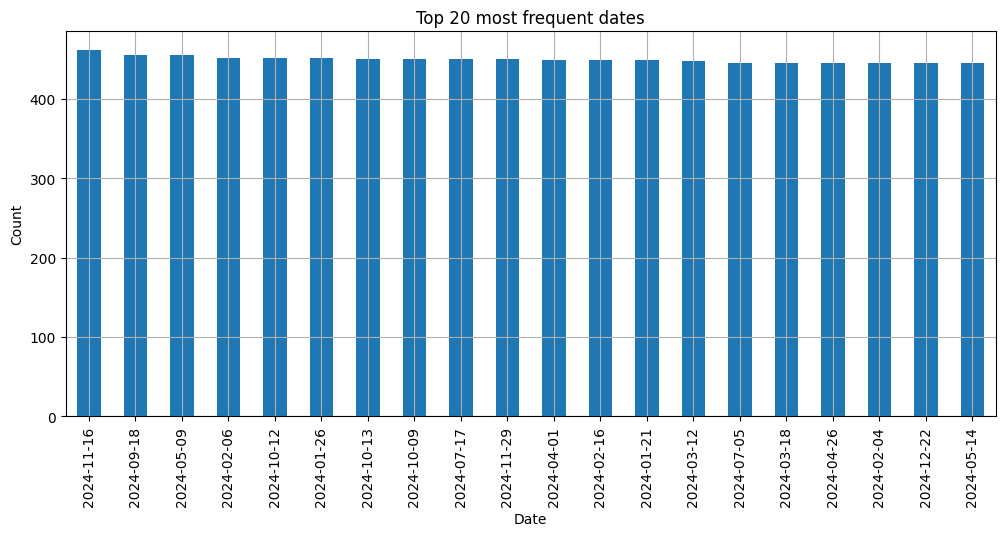

In [7]:
plt.figure(figsize=(12,5))
date_counts.head(20).plot(kind='bar')
plt.title("Top 20 most frequent dates")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid()
plt.show()


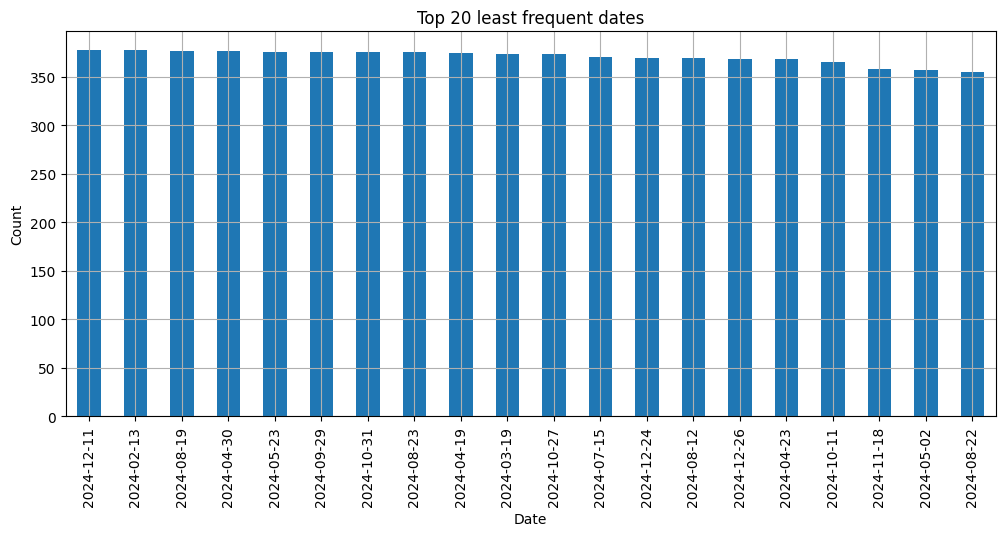

In [8]:
plt.figure(figsize=(12,5))
date_counts.tail(20).plot(kind='bar')
plt.title("Top 20 least frequent dates")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid()
plt.show()


The range bookings in the top 20 days is of 17 bookings. That is interesting. Why is this the maximum number? Was it coincidence? Do we have a bottleneck somewhere? Is it the local record of the city we are analyzing? 

Every day of the year has between 350 and 460 records aprox

It would be interesting to check if those are special days of the year and which is the relationship with cancellations (the amount is the real maximum demand of the service or that flattening is caused by, for example, some service need of improvement)

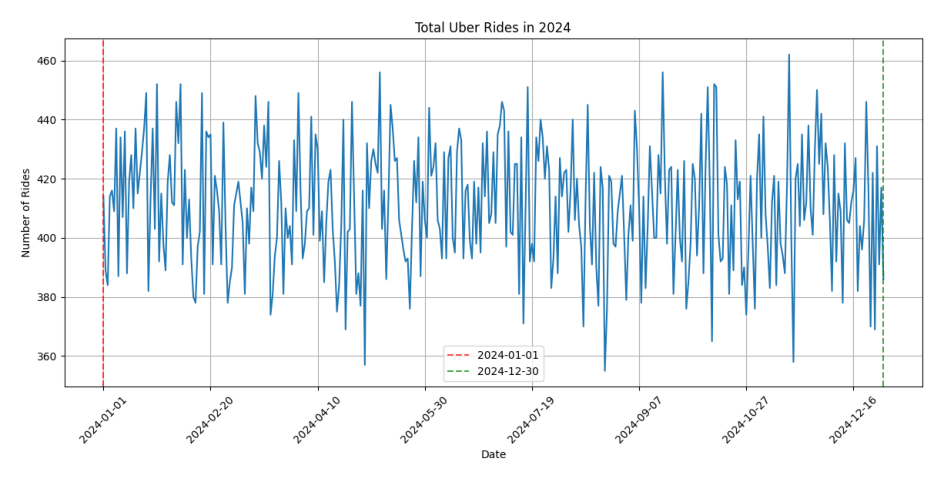

In [9]:
plot_file = 'imgs/date_lineplot.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    daily_counts = data.groupby('date').size()
    plt.plot(daily_counts.index, daily_counts.values)

    first_date = daily_counts.index.min()
    last_date = daily_counts.index.max()
    first_date_label = daily_counts.index.min()
    last_date_label = daily_counts.index.max()
    plt.axvline(first_date, color='red', linestyle='--', alpha=0.7, label=first_date_label)
    plt.axvline(last_date, color='green', linestyle='--', alpha=0.7, label=last_date_label)
    plt.title('Total Uber Rides in 2024')
    plt.xlabel('Date')
    plt.ylabel('Number of Rides')

    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.grid()
    plt.legend()
    plt.tight_layout()
    os.makedirs('imgs', exist_ok=True) 
    plt.savefig(plot_file)
    plt.show()



how can I have 365 unique values if the 31st of Dec does not appear? Maybe there is a 29th of Feb? 

In [10]:
data[data["date"] == "2024-02-29"].head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
24403,2024-02-29,00:00:09,CNR2330207,CID8309113,Auto,Kirti Nagar,Sonipat,9.3,NaN,NaN,NaN,NaN,1.0
24404,2024-02-29,00:08:57,CNR6004216,CID5184316,Go Mini,Meerut,Ghitorni Village,2.8,21.799999,621.0,6.470000,Credit Card,0.0
24405,2024-02-29,00:24:06,CNR1464111,CID1168333,Premier Sedan,Malviya Nagar,Udyog Vihar,3.2,20.200001,444.0,28.160000,Cash,0.0
24406,2024-02-29,00:36:19,CNR3852671,CID4695190,Premier Sedan,Malviya Nagar,Connaught Place,NaN,NaN,NaN,NaN,NaN,1.0
24407,2024-02-29,01:10:18,CNR9446862,CID3841042,Bike,Okhla,Sarojini Nagar,3.7,25.400000,362.0,37.630001,Credit Card,0.0


Ok, it's a leap year



### time

In [11]:
time_length = data["date"].str.len()

print("\nUnique lengths of date strings:", time_length.unique())
print("Counts per length:")
print(time_length.value_counts())



Unique lengths of date strings: [10]
Counts per length:
date
10    150000
Name: count, dtype: int64


In [12]:
time = data['time'].value_counts()
print("\nTop 20 most frequent dates:")
time.head(20)


Top 20 most frequent dates:


time
17:44:57    16
19:17:33    12
17:54:33    11
18:59:55    11
17:55:08    11
11:29:50    11
19:26:48    11
10:23:23    11
15:23:56    11
19:29:07    10
17:38:15    10
18:07:46    10
18:09:57    10
17:34:15    10
18:17:18    10
20:46:08    10
16:16:59    10
19:44:48    10
18:10:37    10
09:45:20    10
Name: count, dtype: int64

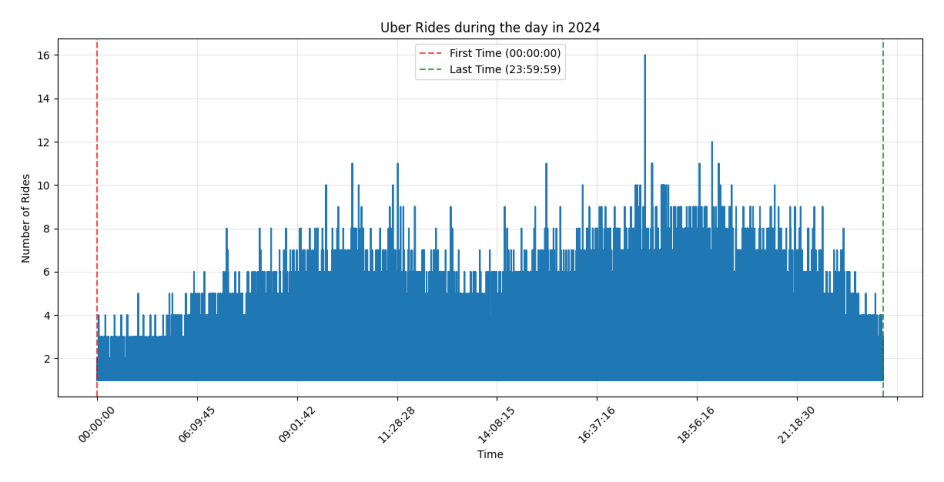

In [13]:
plot_file = 'imgs/time_lineplot.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()
else:
    plt.figure(figsize=(12, 6))

    time_counts = data.groupby('time').size().sort_index()
    plt.plot(time_counts.index, time_counts.values)

    first_time = time_counts.index.min()
    last_time = time_counts.index.max()
    plt.axvline(first_time, color='red', linestyle='--', alpha=0.7, label=f'First Time ({first_time})')
    plt.axvline(last_time, color='green', linestyle='--', alpha=0.7, label=f'Last Time ({last_time})')

    plt.title('Uber Rides during the day in 2024')
    plt.xlabel('Time')
    plt.ylabel('Number of Rides')

    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    os.makedirs('imgs', exist_ok=True) 
    plt.savefig(plot_file)
    plt.show()


As expected there is so much data because of the seconds that I cannot even see the full lineplot. Let's group by other time units

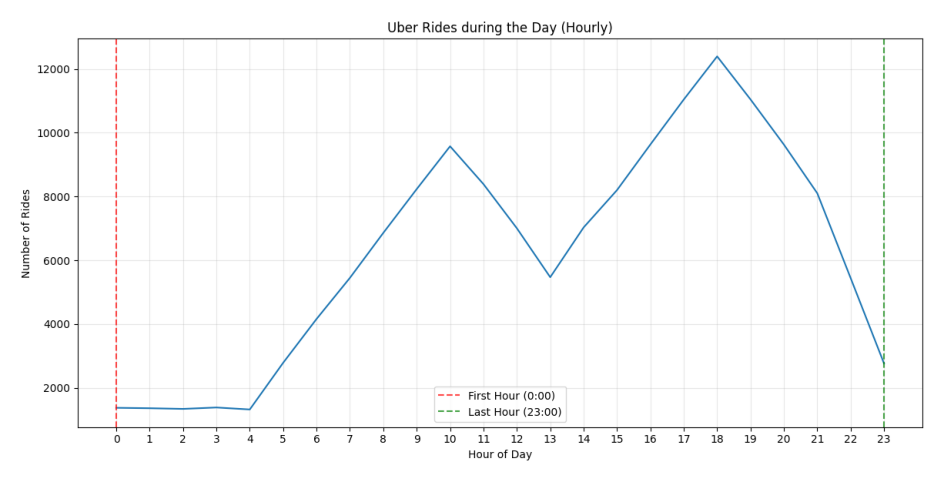

In [14]:
plot_file = 'imgs/time_lineplot_hour.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    data['time'] = pd.to_datetime(data['time'])
    time_counts = (
        data
        .groupby(data['time'].dt.hour)
        .size()
        .sort_index()
    )

    plt.plot(time_counts.index, time_counts.values)

    first_time = time_counts.index.min()
    last_time = time_counts.index.max()
    plt.axvline(first_time, color='red', linestyle='--', alpha=0.7, label=f'First Hour ({first_time}:00)')
    plt.axvline(last_time, color='green', linestyle='--', alpha=0.7, label=f'Last Hour ({last_time}:00)')

    plt.title('Uber Rides during the Day (Hourly)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Rides')

    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    os.makedirs('imgs', exist_ok=True)
    plt.savefig(plot_file)
    plt.show()


The plot shows a clear bimodal daily pattern in Uber ride demand. Activity is minimal during the early morning hours, increases sharply during the morning commute with a peak around 10 AM, dips around midday, and reaches its highest level in the early evening (around 6 PM). Demand then steadily declines toward the end of the day

### new date + time related features

In [15]:
# the 1st of January of 2024 was Monday

data['datetime'] = pd.to_datetime(data['date'] + " " + data['time'], format="%Y-%m-%d %H:%M:%S")

# since there is a clear pattern seen in "time" I create "hour"
data['hour'] = data['datetime'].dt.hour
data['weekday'] = data['datetime'].dt.weekday
data['is_weekend'] = data['weekday'] >= 5

data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)


weekday
0    408.377358
1    411.365385
2    411.788462
3    407.980769
4    411.480769
5    414.269231
6    411.500000
dtype: float64


<Axes: title={'center': 'Average Activity per Weekday (Normalized)'}, xlabel='weekday'>

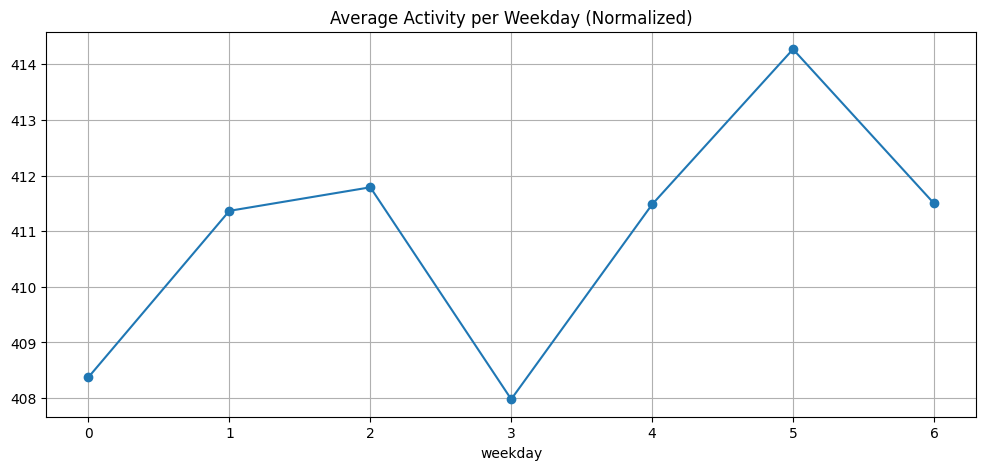

In [16]:
# How is the behaviour of each day?

weekday_counts = data.groupby('weekday').size()

days_per_weekday = data.groupby('weekday')['date'].nunique()
normalized_weekday = weekday_counts / days_per_weekday
print(normalized_weekday)

normalized_weekday.plot(
    kind='line',
    marker='o',
    figsize=(12,5),
    title="Average Activity per Weekday (Normalized)",
    grid=True
)



There is no clear difference between weekdays in this plot; the number of bookings appears to be approximately the same each day 

is_weekend
False    410.191571
True     412.884615
dtype: float64


<Axes: title={'center': 'Average Activity per Day (Weekend vs Weekday)'}, xlabel='is_weekend'>

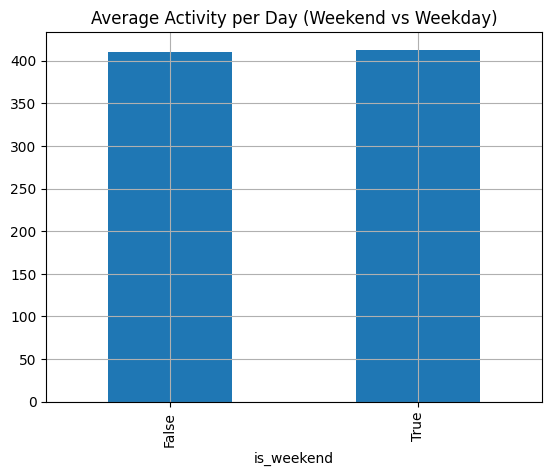

In [17]:
# Is the behaviour changing in the weekend? 

avg_activity = (
    data.groupby('is_weekend')
        .size()
        / data.groupby('is_weekend')['date'].nunique()
)
print(avg_activity)

avg_activity.plot(
    kind='bar',
    title='Average Activity per Day (Weekend vs Weekday)',
    grid=True
)


After normalizing by the number of days, weekend and weekday activity levels are comparable, indicating no strong weekend effect

In [18]:
data[["hour_sin", "hour_cos"]].describe()

,hour_sin,hour_cos
count,150000.000000,150000.000000
mean,-0.242204,-0.212834
std,0.714842,0.620520
min,-1.000000,-1.000000
25%,-0.866025,-0.707107
50%,-0.500000,-0.258819
75%,0.500000,0.258819
max,1.000000,1.000000


Expected: min ≈ -1, max ≈ 1, mean ≈ 0, perfect

To capture the cyclical nature of time, the hour of day was encoded using sine and cosine transformations. This representation preserves the circular structure of time, ensuring that adjacent hours such as 23:00 and 00:00 are represented as similar values.

### booking_id


In [19]:
# format check

data['booking_length'] = data['booking_id'].str.len()
print(f"Unique lengths of time strings: {data['booking_length'].nunique()}\n")
print(f"Counts per length: {data['booking_length'].value_counts().sum()}")

# there are no errors on the booking_id formats


Unique lengths of time strings: 1

Counts per length: 150000


In [20]:
# what is the letter code in fron of the number? how many do we have? 
import re

data[["letters_b", "numbers_b"]] = data["booking_id"].str.extract(
    r"([A-Za-z]+)([0-9]+)"
)

count_letters_b = data["letters_b"].value_counts(dropna = False)
count_numbers_b = data["numbers_b"].value_counts(dropna = False)

# are the values in front of the numbers valuable?
count_letters_b
# count_numbers_b

letters_b
CNR    150000
Name: count, dtype: Int64

All rows share the same letter code "CNR", the number is the unique identifier.

In [21]:
# what is the range of the numbers?

count_numbers = count_numbers_b.astype("int32").sort_index()
print(f" The min value is: {count_numbers_b.idxmin()}, the max value is: {count_numbers_b.idxmax()}")


 The min value is: 1405409, the max value is: 2726142


In [22]:
# how many duplicated booking IDs and how many times? why?

pd.set_option("display.max_columns", None)
multiple_bookings = data[data["booking_id"].duplicated(keep=False)]
print(f" There are {len(multiple_bookings)} duplicated")
multiple_bookings

 There are 2457 duplicated


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b
58,2024-01-01,07:43:08,CNR5998244,CID7994710,Go Mini,Samaypur Badli,Kanhaiya Nagar,NaN,NaN,NaN,NaN,NaN,1.0,2024-01-01 07:43:08,7,0,False,0.965926,-2.588190e-01,10,CNR,5998244
69,2024-01-01,08:32:24,CNR6472828,CID6596558,Go Sedan,Madipur,Mansarovar Park,9.7,23.900000,213.0,10.560000,UPI,0.0,2024-01-01 08:32:24,8,0,False,0.866025,-5.000000e-01,10,CNR,6472828
215,2024-01-01,15:54:12,CNR4156724,CID4908411,Bike,Panipat,Gurgaon Sector 29,5.6,NaN,NaN,NaN,NaN,1.0,2024-01-01 15:54:12,15,0,False,-0.707107,-7.071068e-01,10,CNR,4156724
263,2024-01-01,17:39:02,CNR2127822,CID2082356,Go Sedan,Anand Vihar ISBT,Keshav Puram,4.6,NaN,NaN,NaN,NaN,1.0,2024-01-01 17:39:02,17,0,False,-0.965926,-2.588190e-01,10,CNR,2127822
297,2024-01-01,18:47:45,CNR9542022,CID8537493,Go Sedan,Shastri Nagar,Paschim Vihar,6.8,NaN,NaN,NaN,NaN,1.0,2024-01-01 18:47:45,18,0,False,-1.000000,-1.836970e-16,10,CNR,9542022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149734,2024-12-30,11:33:04,CNR4925969,CID8916592,Bike,Malviya Nagar,Indirapuram,11.4,43.900002,458.0,44.209999,Cash,0.0,2024-12-30 11:33:04,11,0,False,0.258819,-9.659258e-01,10,CNR,4925969
149806,2024-12-30,15:30:51,CNR5567305,CID7210910,Auto,Meerut,DLF Phase 3,2.0,25.000000,166.0,30.620001,UPI,0.0,2024-12-30 15:30:51,15,0,False,-0.707107,-7.071068e-01,10,CNR,5567305
149891,2024-12-30,18:18:50,CNR1143952,CID6138660,Bike,IGI Airport,Rajouri Garden,3.0,18.900000,406.0,21.500000,Debit Card,0.0,2024-12-30 18:18:50,18,0,False,-1.000000,-1.836970e-16,10,CNR,1143952
149907,2024-12-30,18:38:38,CNR7781315,CID9693057,Bike,Indraprastha,Green Park,12.3,NaN,NaN,NaN,NaN,1.0,2024-12-30 18:38:38,18,0,False,-1.000000,-1.836970e-16,10,CNR,7781315


In [23]:
# duplicated twice 

counts_bookings = data["booking_id"].value_counts()
ids_duplicated_twice = counts_bookings[counts_bookings == 2].index
duplicates_twice = data[data["booking_id"].isin(ids_duplicated_twice)].sort_values(["booking_id", "date", "time"])
print(f" There are {len(duplicates_twice)} rows duplicated two times")
duplicates_twice.head(4)

 There are 2430 rows duplicated two times


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b
83526,2024-07-21,17:59:41,CNR1026036,CID6974869,Go Mini,Seelampur,Nehru Place,NaN,NaN,NaN,NaN,NaN,1.0,2024-07-21 17:59:41,17,6,True,-0.965926,-2.588190e-01,10,CNR,1026036
118826,2024-10-15,18:17:23,CNR1026036,CID6480133,Go Mini,Khandsa,Ashok Vihar,3.8,43.299999,102.0,36.509998,UPI,0.0,2024-10-15 18:17:23,18,1,False,-1.000000,-1.836970e-16,10,CNR,1026036
7709,2024-01-19,17:00:57,CNR1029172,CID2615731,Bike,Jhilmil,Narsinghpur,4.7,26.700001,429.0,16.160000,UPI,0.0,2024-01-19 17:00:57,17,4,False,-0.965926,-2.588190e-01,10,CNR,1029172
144662,2024-12-17,19:19:02,CNR1029172,CID6382731,Auto,Inderlok,Laxmi Nagar,6.9,34.400002,332.0,36.380001,UPI,0.0,2024-12-17 19:19:02,19,1,False,-0.965926,2.588190e-01,10,CNR,1029172


Uber is using booking IDs in different ways: 

1. For example "CNR1026036", is cancelled and then user 3 months later
2. Another case is for example "CNR1029172" that has been used two times

Both cases represent a misuse of IDs, that are reused without need and also duplicated representing clearly different rides. It would be important to report this issue.
   

In [24]:
# duplicated thrice 

ids_duplicated_thrice = counts_bookings[counts_bookings == 3].index
duplicates_thrice = data[data["booking_id"].isin(ids_duplicated_thrice)].sort_values(["booking_id", "date", "time"])
print(f" There are {len(duplicates_thrice)} rows duplicated three times")
duplicates_thrice.head(9)

 There are 27 rows duplicated three times


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b
58520,2024-05-22,10:58:23,CNR2726142,CID6203511,Go Mini,Chanakyapuri,Sultanpur,7.9,29.400000,486.0,7.090000,UPI,0.0,2024-05-22 10:58:23,10,2,False,5.000000e-01,-0.866025,10,CNR,2726142
69768,2024-06-18,14:38:50,CNR2726142,CID9496782,Go Sedan,Madipur,Panchsheel Park,8.9,26.100000,746.0,16.340000,Uber Wallet,0.0,2024-06-18 14:38:50,14,1,False,-5.000000e-01,-0.866025,10,CNR,2726142
106506,2024-09-15,20:51:23,CNR2726142,CID7293070,Premier Sedan,Sadar Bazar Gurgaon,Laxmi Nagar,2.1,24.299999,1269.0,14.230000,UPI,0.0,2024-09-15 20:51:23,20,6,True,-8.660254e-01,0.500000,10,CNR,2726142
67504,2024-06-13,04:26:17,CNR3648267,CID1753108,Auto,Yamuna Bank,Ashram,13.6,43.599998,426.0,46.910000,UPI,0.0,2024-06-13 04:26:17,4,3,False,8.660254e-01,0.500000,10,CNR,3648267
124672,2024-10-30,09:59:12,CNR3648267,CID2936917,Auto,Madipur,Vinobapuri,3.2,24.299999,268.0,32.419998,UPI,0.0,2024-10-30 09:59:12,9,2,False,7.071068e-01,-0.707107,10,CNR,3648267
128007,2024-11-07,12:04:55,CNR3648267,CID4806406,Go Mini,Greater Kailash,Vatika Chowk,10.9,24.900000,200.0,28.200001,UPI,0.0,2024-11-07 12:04:55,12,3,False,1.224647e-16,-1.000000,10,CNR,3648267
6146,2024-01-15,21:59:33,CNR5292943,CID4333861,Auto,Chirag Delhi,Peeragarhi,5.7,30.000000,598.0,7.640000,Uber Wallet,0.0,2024-01-15 21:59:33,21,0,False,-7.071068e-01,0.707107,10,CNR,5292943
25983,2024-03-03,21:54:03,CNR5292943,CID8651844,Auto,Hauz Khas,Nehru Place,5.6,23.100000,633.0,26.450001,UPI,0.0,2024-03-03 21:54:03,21,6,True,-7.071068e-01,0.707107,10,CNR,5292943
67095,2024-06-12,02:49:04,CNR5292943,CID4424381,Bike,IFFCO Chowk,Rajiv Chowk,7.3,43.299999,720.0,30.650000,Credit Card,0.0,2024-06-12 02:49:04,2,2,False,5.000000e-01,0.866025,10,CNR,5292943


By having an overview of the rows repeated 3 times, I can see that these rows are completely different from one another. The information of the dataset describes this column as an unique identifier so there is clearly a problem. 

In [25]:
# Does each row increment by 1 compared to the previous row?
nums = data["numbers_b"].astype("int32")
diffs = nums.diff()

breaks = data.loc[diffs.ne(1) & diffs.notna(), "numbers_b"]

print("Is strictly consecutive:", (diffs.dropna() == 1).all())
print("Break points:")
print(len(breaks))
print(breaks)


Is strictly consecutive: False
Break points:
149999
1         9147645
2         1009222
3         2740479
4         7650148
5         8140858
           ...   
149995    9030698
149996    1507833
149997    2265113
149998    4066733
149999    6915581
Name: numbers_b, Length: 149999, dtype: string


I guess that booking_ids are probably based on the vehicle_type and defined by every vehicle service 

### customer_id

In [26]:
# format check

data['customer_length'] = data['customer_id'].str.len()
print(f"Unique lengths of time strings: {data['customer_length'].nunique()}\n")
print(f"Counts per length: {data['customer_length'].value_counts().sum()}")

# there are no errors on the customer_id formats

Unique lengths of time strings: 1

Counts per length: 150000


In [27]:

data[["letters_c", "numbers_c"]] = data["customer_id"].str.extract(
    r"([A-Za-z]+)([0-9]+)"
)

count_letters_c = data["letters_c"].value_counts(dropna = False)
count_numbers_c = data["numbers_c"].value_counts(dropna = False)

# are the values in front of the numbers valuable?
count_letters_c
# count_numbers_c

letters_c
CID    150000
Name: count, dtype: Int64

All rows share the same letter code "CID"

In [28]:
# what is the range of the numbers?

count_numbers_c = count_numbers_c.astype("int32").sort_index()
print(f" The min value is: {count_numbers_c.idxmin()}, the max value is: {count_numbers_c.idxmax()}")


 The min value is: 1000119, the max value is: 4523979


In [29]:
# how many duplicated booking IDs and how many times? why?

pd.set_option("display.max_columns", None)
duplicates = data[data["customer_id"].duplicated(keep=False)]
print(f" Duplicated rows: {len(duplicates)}")

 Duplicated rows: 2418


In [30]:
# duplicated customers 

counts_customers = data["customer_id"].value_counts()
ids_duplicated_twice = counts_customers[counts_customers == 2].index
duplicated_customers = data[data["customer_id"].isin(ids_duplicated_twice)].sort_values(["customer_id", "date", "time"])
print(f" There are {len(duplicated_customers)} rows duplicated twice")
duplicated_customers.head(4)

 There are 2400 rows duplicated twice


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
32247,2024-03-18,20:44:08,CNR9208385,CID1008198,Auto,Noida Sector 62,Karkarduma,12.8,25.600000,572.0,25.24,UPI,0.0,2024-03-18 20:44:08,20,0,False,-0.866025,0.500000,10,CNR,9208385,10,CID,1008198
35935,2024-03-28,09:04:44,CNR6195473,CID1008198,Premier Sedan,Aya Nagar,Ghaziabad,8.5,NaN,NaN,NaN,NaN,1.0,2024-03-28 09:04:44,9,3,False,0.707107,-0.707107,10,CNR,6195473,10,CID,1008198
25436,2024-03-02,17:37:00,CNR9673455,CID1008784,Premier Sedan,RK Puram,Subhash Nagar,3.7,29.200001,217.0,49.32,Uber Wallet,0.0,2024-03-02 17:37:00,17,5,True,-0.965926,-0.258819,10,CNR,9673455,10,CID,1008784
63560,2024-06-03,15:56:24,CNR4575076,CID1008784,Bike,RK Puram,Green Park,9.0,33.099998,90.0,32.75,Uber Wallet,0.0,2024-06-03 15:56:24,15,0,False,-0.707107,-0.707107,10,CNR,4575076,10,CID,1008784


In [31]:
# triplicated customers

ids_duplicated_thrice = counts_customers[counts_customers == 3].index
triplicated_customers = data[data["customer_id"].isin(ids_duplicated_thrice)].sort_values(["customer_id", "date", "time"])
print(f" There are {len(triplicated_customers)} rows duplicated thrice")
triplicated_customers.head(20)

 There are 18 rows duplicated thrice


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
12822,2024-01-31,20:52:22,CNR2186599,CID4523979,Premier Sedan,Tis Hazari,Nawada,10.4,25.299999,597.0,29.980000,Uber Wallet,0.0,2024-01-31 20:52:22,20,2,False,-8.660254e-01,5.000000e-01,10,CNR,2186599,10,CID,4523979
23413,2024-02-26,16:23:31,CNR1088509,CID4523979,Go Sedan,Punjabi Bagh,Laxmi Nagar,3.3,27.400000,142.0,39.220001,UPI,0.0,2024-02-26 16:23:31,16,0,False,-8.660254e-01,-5.000000e-01,10,CNR,1088509,10,CID,4523979
46232,2024-04-22,12:35:18,CNR1120552,CID4523979,Go Sedan,Shivaji Park,Bhikaji Cama Place,5.5,37.599998,208.0,13.920000,UPI,0.0,2024-04-22 12:35:18,12,0,False,1.224647e-16,-1.000000e+00,10,CNR,1120552,10,CID,4523979
35974,2024-03-28,10:31:13,CNR1395642,CID5481002,Go Mini,Yamuna Bank,Faridabad Sector 15,2.7,18.299999,340.0,5.680000,Credit Card,0.0,2024-03-28 10:31:13,10,3,False,5.000000e-01,-8.660254e-01,10,CNR,1395642,10,CID,5481002
41701,2024-04-11,03:48:54,CNR2916840,CID5481002,Auto,MG Road,Barakhamba Road,3.1,41.400002,272.0,42.970001,Uber Wallet,0.0,2024-04-11 03:48:54,3,3,False,7.071068e-01,7.071068e-01,10,CNR,2916840,10,CID,5481002
67305,2024-06-12,16:35:03,CNR6012577,CID5481002,Bike,Govindpuri,Peeragarhi,9.2,NaN,NaN,NaN,NaN,1.0,2024-06-12 16:35:03,16,2,False,-8.660254e-01,-5.000000e-01,10,CNR,6012577,10,CID,5481002
17955,2024-02-13,10:29:03,CNR7782378,CID6468528,Bike,Madipur,Pulbangash,2.8,17.500000,472.0,1.700000,UPI,0.0,2024-02-13 10:29:03,10,1,False,5.000000e-01,-8.660254e-01,10,CNR,7782378,10,CID,6468528
68449,2024-06-15,11:06:24,CNR2810893,CID6468528,Premier Sedan,Mayur Vihar,Barakhamba Road,8.9,43.599998,1078.0,39.150002,UPI,0.0,2024-06-15 11:06:24,11,5,True,2.588190e-01,-9.659258e-01,10,CNR,2810893,10,CID,6468528
125801,2024-11-02,05:56:53,CNR8569643,CID6468528,Go Mini,ITO,Saket,8.9,NaN,NaN,NaN,NaN,1.0,2024-11-02 05:56:53,5,5,True,9.659258e-01,2.588190e-01,10,CNR,8569643,10,CID,6468528
13613,2024-02-02,19:52:21,CNR8684613,CID6715450,eBike,Kashmere Gate ISBT,Karol Bagh,NaN,NaN,NaN,NaN,NaN,1.0,2024-02-02 19:52:21,19,4,False,-9.659258e-01,2.588190e-01,10,CNR,8684613,10,CID,6715450


In [32]:
# what is the percentage of customers that used the service two times and cancelled? 

duplicated_cancelled = duplicated_customers[duplicated_customers["is_cancelled"] == 1.0]
perc_duplicated_cancelled = round((len(duplicated_cancelled)/len(duplicated_customers)) * 100, 2)
print(f" The percentage of duplicated customers that have been cancelled: {perc_duplicated_cancelled} %")

 The percentage of duplicated customers that have been cancelled: 32.75 %


In [33]:
# what is the percentage of customers that used the service more than twice and cancelled? 

triplicated_cancelled = triplicated_customers[triplicated_customers["is_cancelled"] == 1.0]
perc_triplicated_cancelled = round((len(triplicated_cancelled)/len(triplicated_customers)) * 100, 2)
print(f" The percentage of triplicated customers that have been cancelled: {perc_triplicated_cancelled} %")

 The percentage of triplicated customers that have been cancelled: 22.22 %


In [34]:
# what is the amount and percentage of unique customers that used the service that cancelled? 

unique_customers = counts_customers[counts_customers == 1].index

unique_users= data[data["customer_id"].isin(unique_customers)]
print(f" There are {len(unique_users)} unique customers")
unique_users.head()


 There are 147582 unique customers


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0,2024-01-01 00:19:34,0,0,False,0.000000,1.000000,10,CNR,4352144,10,CID,8362794
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0,2024-01-01 01:35:18,1,0,False,0.258819,0.965926,10,CNR,9147645,10,CID,8300238
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:37:50,1,0,False,0.258819,0.965926,10,CNR,1009222,10,CID,2030746
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:48:03,1,0,False,0.258819,0.965926,10,CNR,2740479,10,CID,3231181
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:49:56,1,0,False,0.258819,0.965926,10,CNR,7650148,10,CID,3381661


In [35]:
# what is the percentage of the unique customers that cancelled? 

unique_cancelled = unique_users[unique_users["is_cancelled"] == 1.0]
perc_unique_cancelled = round((len(unique_cancelled)/len(unique_users)) * 100, 2)
print(f" The percentage of unique customers that have been cancelled: {perc_unique_cancelled} %")

 The percentage of unique customers that have been cancelled: 31.99 %


I will leave the analysis of cancellations within each multiple customer
total percentage of cancelled?

### vehicle_type

In [36]:
# what is the distribution? how many types do we have? are all of them valid? 

In [37]:
vehicle_counts = data["vehicle_type"].value_counts(dropna = False)
vehicle_counts

vehicle_type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

In [38]:
vehicle_counts.index.to_list()

['Auto', 'Go Mini', 'Go Sedan', 'Bike', 'Premier Sedan', 'eBike', 'Uber XL']

<Axes: xlabel='vehicle_type'>

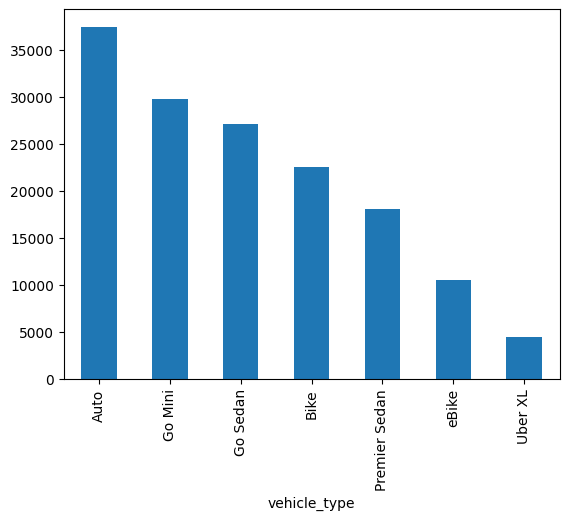

In [39]:
vehicle_counts.plot(kind = "bar")

### pickup_location

In [40]:
# how is the distribution of the pickup locations? are they all valid?  

In [41]:
pd.set_option("display.max_rows", None)

pickups = data["pickup_location"].value_counts(dropna = False)
pickups

pickup_location
Khandsa                      949
Barakhamba Road              946
Saket                        931
Badarpur                     921
Pragati Maidan               920
Madipur                      919
AIIMS                        918
Mehrauli                     915
Dwarka Sector 21             914
Pataudi Chowk                907
Tilak Nagar                  900
Shivaji Park                 900
Udyog Vihar                  897
Greater Kailash              895
Vishwavidyalaya              895
Kanhaiya Nagar               895
Tagore Garden                889
Subhash Chowk                887
Inderlok                     887
Jasola                       887
Malviya Nagar                885
Nehru Place                  885
Jahangirpuri                 884
Ashok Park Main              884
Jor Bagh                     884
Rajiv Nagar                  884
Noida Film City              883
New Colony                   881
Nawada                       880
Lok Kalyan Marg            

I don't have enough knowledge to check if all the pickup locations are properly formatted but we should check this

In [42]:
print(f" The is a total of {len(pickups)} different pickup locations")

 The is a total of 176 different pickup locations


In [43]:
# which are the most and least frequent pickup locations? 

print(f" The min value is: {pickups.min()}, the max value is: {pickups.max()}")


 The min value is: 790, the max value is: 949


<Axes: xlabel='pickup_location'>

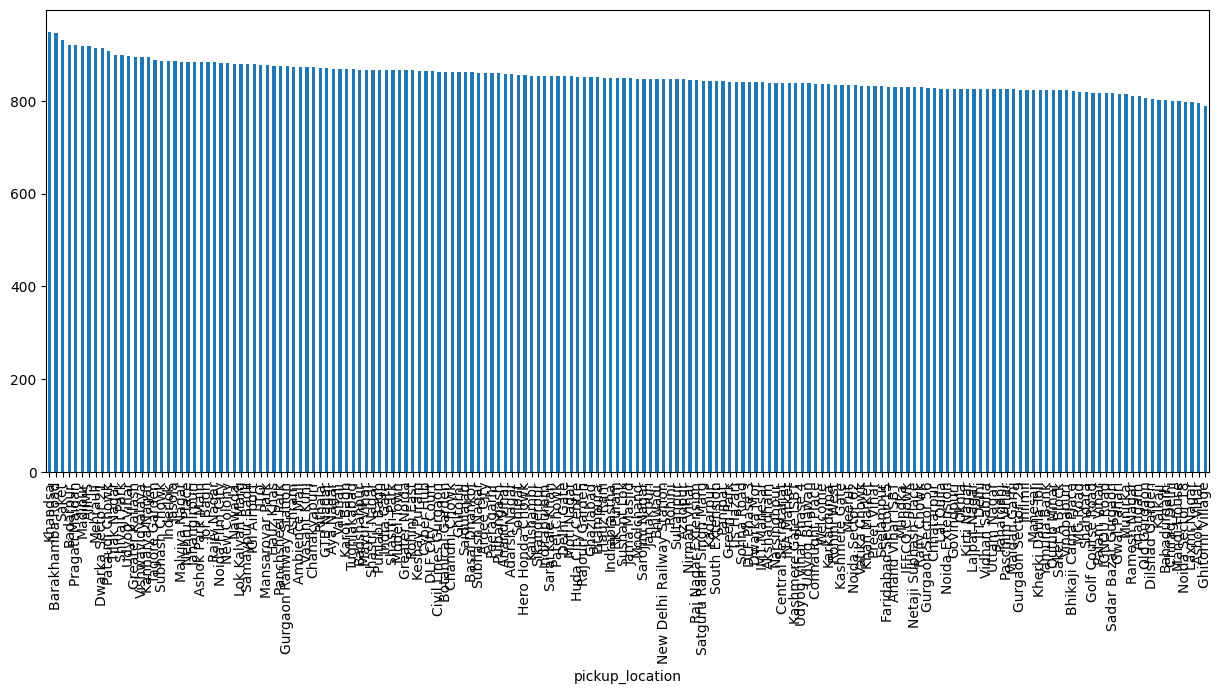

In [44]:
pickups.plot(kind = "bar", figsize=(15,6))

### drop location

In [45]:
# how is the distribution of the drop locations? are they all valid?  

In [46]:
drops = data["drop_location"].value_counts(dropna = False)
drops

drop_location
Ashram                       936
Basai Dhankot                917
Lok Kalyan Marg              916
Narsinghpur                  913
Cyber Hub                    912
Kalkaji                      912
Kashmere Gate ISBT           909
Udyog Vihar                  906
Lajpat Nagar                 904
Nehru Place                  902
Madipur                      902
Punjabi Bagh                 901
Shastri Nagar                901
Moolchand                    899
Sarai Kale Khan              896
Gurgaon Sector 56            894
Hauz Khas                    892
Gurgaon Railway Station      891
New Colony                   890
Paharganj                    887
South Extension              887
Uttam Nagar                  883
Preet Vihar                  882
Samaypur Badli               881
Dilshad Garden               879
Gwal Pahari                  878
Ghaziabad                    878
Sultanpur                    877
Ghitorni                     877
Chirag Delhi                 

In [47]:
print(f" The is a total of {len(drops)} different drop locations")

 The is a total of 176 different drop locations


In [48]:
# which are the most and least frequent drop locations? 

print(f" The min value is: {drops.min()}, the max value is: {drops.max()}")

 The min value is: 774, the max value is: 936


<Axes: xlabel='drop_location'>

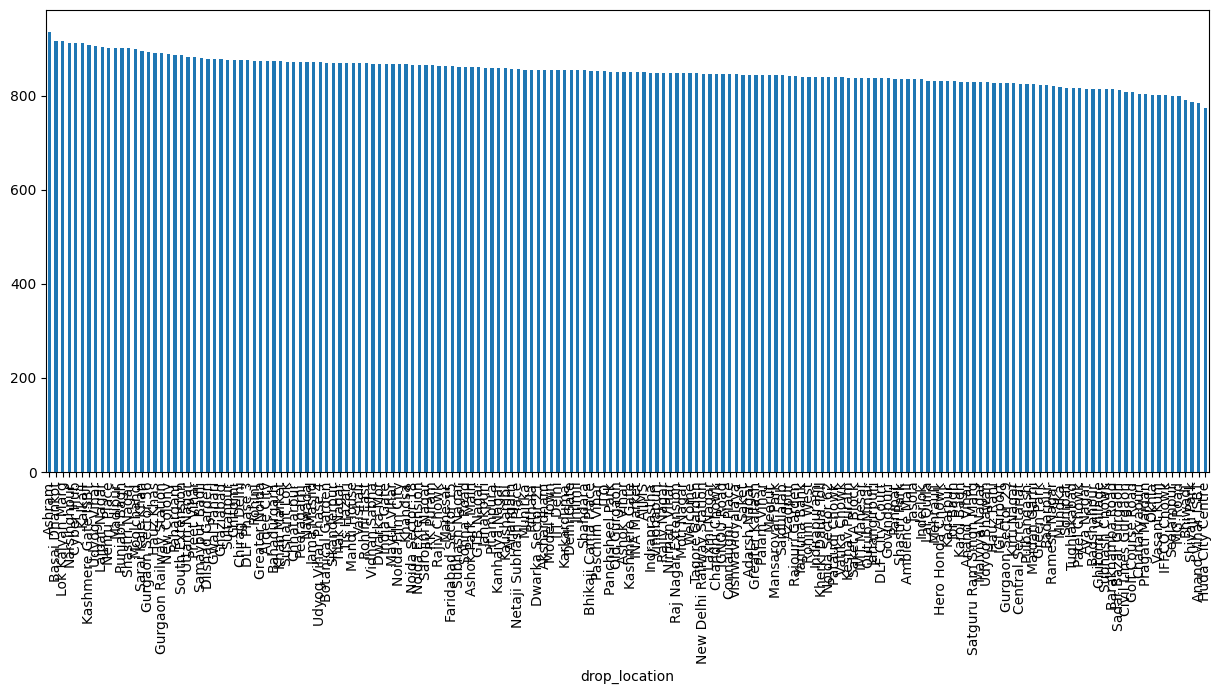

In [49]:
drops.plot(kind = "bar", figsize=(15,6))

### avg_vtat

Average time for driver to reach the pickup location (in minutes)

In [50]:
# from stats I can see that there are NaNs, why? do they mean something?
# distribution

In [51]:
data["avg_vtat"].unique()

array([10.8,  8.5,  7.4,  5.6,  6.2,  8.1, 11.8,  nan,  7.7, 10.4, 14.3,
        6.7,  2.9,  8.6,  5.5, 10.2,  5.3,  3.1,  3.7,  6.8,  4.8, 14.5,
        3.4,  5.1, 12.1,  5.4, 13.8, 16.8,  4.1,  8.2, 13.1,  7.5,  6.6,
       12.9,  6.5,  6.1,  4.6,  6.3,  9.3, 14.7, 11.5, 13.3,  9.9,  7.8,
       11.4, 13. ,  7.9,  3. ,  8.3,  8.9,  9.7,  8.8,  3.9, 13.7,  3.6,
       12.6, 12.4, 10.3, 11.6,  3.2, 18.3,  2.3,  6.9, 11.3, 11.7,  4.5,
        4.7,  2.2,  2.4,  7.2, 10.6,  7.1,  4.4, 13.6,  6. ,  2.8,  4.3,
        6.4, 19. ,  2.1, 12. ,  2.5,  9.5, 11. , 11.1, 10.5, 12.8,  8.4,
        3.3,  4.2,  4.9, 12.2,  4. ,  2.7,  5.2, 14.1, 16.6,  3.8, 12.7,
       12.5,  9.2, 12.3,  9.1,  2.6, 11.9,  7. ,  5. ,  3.5, 15.2, 14.4,
        5.7, 14.9,  2. , 10.7, 18.2,  9.4, 13.4,  5.8, 19.2,  9. ,  7.6,
       10.1, 15.5, 14.2,  7.3, 19.7,  8.7,  8. , 11.2, 13.9,  5.9, 10. ,
       16.7, 14.8, 10.9,  9.8, 15.6, 19.9, 13.5, 17.6, 15.1, 16.2, 14. ,
       15.4, 14.6, 15. , 18. ,  9.6, 16.9, 19.4, 13

In [52]:
print(f"Total unique values: {data['avg_vtat'].nunique()}")

Total unique values: 181


In [53]:
# Analysis of NaNs

# how many are they?
# what is their origin / meaning?

In [54]:
print(f"Total NaNs: {data['avg_vtat'].isna().sum()}")

Total NaNs: 10500


In [55]:
data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0,2024-01-01 00:19:34,0,0,False,0.000000,1.000000,10,CNR,4352144,10,CID,8362794
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0,2024-01-01 01:35:18,1,0,False,0.258819,0.965926,10,CNR,9147645,10,CID,8300238
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:37:50,1,0,False,0.258819,0.965926,10,CNR,1009222,10,CID,2030746
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:48:03,1,0,False,0.258819,0.965926,10,CNR,2740479,10,CID,3231181
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:49:56,1,0,False,0.258819,0.965926,10,CNR,7650148,10,CID,3381661


In [56]:
nan_vtat = data[data["avg_vtat"].isna()]
nan_vtat.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
7,2024-01-01,02:43:46,CNR4510033,CID3289424,eBike,Udyog Bhawan,Badarpur,NaN,NaN,NaN,NaN,NaN,1.0,2024-01-01 02:43:46,2,0,False,0.500000,0.866025,10,CNR,4510033,10,CID,3289424
9,2024-01-01,02:59:14,CNR4588428,CID3087143,Auto,Greater Noida,IMT Manesar,NaN,NaN,NaN,NaN,NaN,1.0,2024-01-01 02:59:14,2,0,False,0.500000,0.866025,10,CNR,4588428,10,CID,3087143
44,2024-01-01,07:08:27,CNR4564281,CID1979440,Go Sedan,Janakpuri,Chandni Chowk,NaN,NaN,NaN,NaN,NaN,1.0,2024-01-01 07:08:27,7,0,False,0.965926,-0.258819,10,CNR,4564281,10,CID,1979440
56,2024-01-01,07:33:10,CNR7284122,CID7575243,Go Mini,Rajouri Garden,Munirka,NaN,NaN,NaN,NaN,NaN,1.0,2024-01-01 07:33:10,7,0,False,0.965926,-0.258819,10,CNR,7284122,10,CID,7575243
58,2024-01-01,07:43:08,CNR5998244,CID7994710,Go Mini,Samaypur Badli,Kanhaiya Nagar,NaN,NaN,NaN,NaN,NaN,1.0,2024-01-01 07:43:08,7,0,False,0.965926,-0.258819,10,CNR,5998244,10,CID,7994710


In [57]:
# to confirm in the bivar: 
# relationship between the avg_vtat and the cancellations

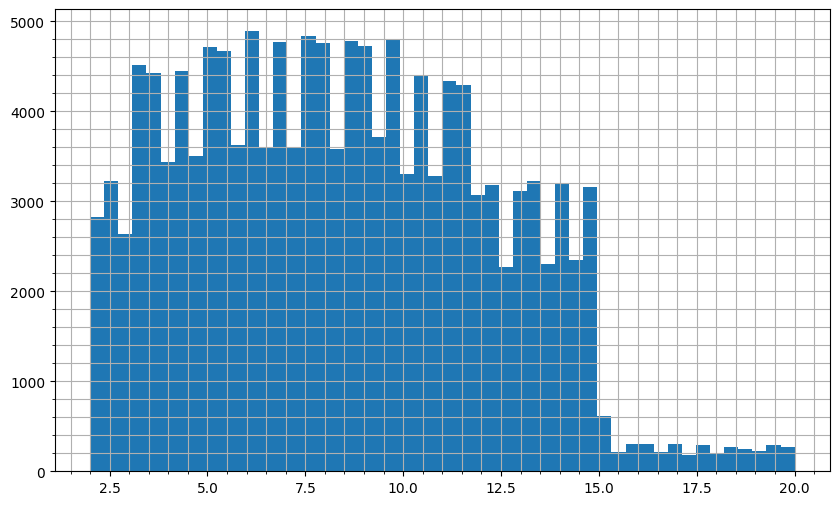

In [75]:
#distribution 
ax = data["avg_vtat"].hist(
    bins=50,
    figsize=(10, 6)
)


ax.minorticks_on()
ax.grid(True, which="both")


There are 3 distinct regions: 
1. Region between 2 and 3 mins with frequencies in the 2600-3200 range. This region is surprisingly hi because rides are usually longer than that. Relationship with target and vehicle has to be checked
2. Region between 3 and 15 mins with high frequencies mostly between 3000 and 5000. Within this region there is some fluctuation with multiple peaks and troughs. There is a big drop around 15.
3. Region between 15 and 20 with very low frequencies around 200-300
   
Along the overall distribution is slightly right-skewed. 

In [59]:
# are there outliers? how many? 

col = "avg_vtat" 

q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr = q3 - q1

outliers = data[(data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)]

len(outliers), len(outliers) / len(data)


(0, 0.0)

### avg_ctat

I gonna ask myself the same questions as avg_vtat

In [60]:
print(f"Total unique values: {data['avg_ctat'].nunique()}")

Total unique values: 351


In [61]:
print(f"Total NaNs: {data['avg_ctat'].isna().sum()}")

Total NaNs: 48000


in this case there are more NaNs, let's see their characteristics

In [62]:
nan_ctat = data[data["avg_ctat"].isna()]
nan_ctat.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:37:50,1,0,False,0.258819,0.965926,10,CNR,1009222,10,CID,2030746
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:48:03,1,0,False,0.258819,0.965926,10,CNR,2740479,10,CID,3231181
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:49:56,1,0,False,0.258819,0.965926,10,CNR,7650148,10,CID,3381661
6,2024-01-01,02:14:50,CNR8839592,CID6577042,Bike,Jama Masjid,Sadar Bazar Gurgaon,11.8,NaN,NaN,NaN,NaN,1.0,2024-01-01 02:14:50,2,0,False,0.500000,0.866025,10,CNR,8839592,10,CID,6577042
7,2024-01-01,02:43:46,CNR4510033,CID3289424,eBike,Udyog Bhawan,Badarpur,NaN,NaN,NaN,NaN,NaN,1.0,2024-01-01 02:43:46,2,0,False,0.500000,0.866025,10,CNR,4510033,10,CID,3289424


In [63]:
# for the bivar:
# how are the rows that have avg_vtat but no avg_ctat? what does it mean? which characteristics they have? 
# how is the relationship with target? 

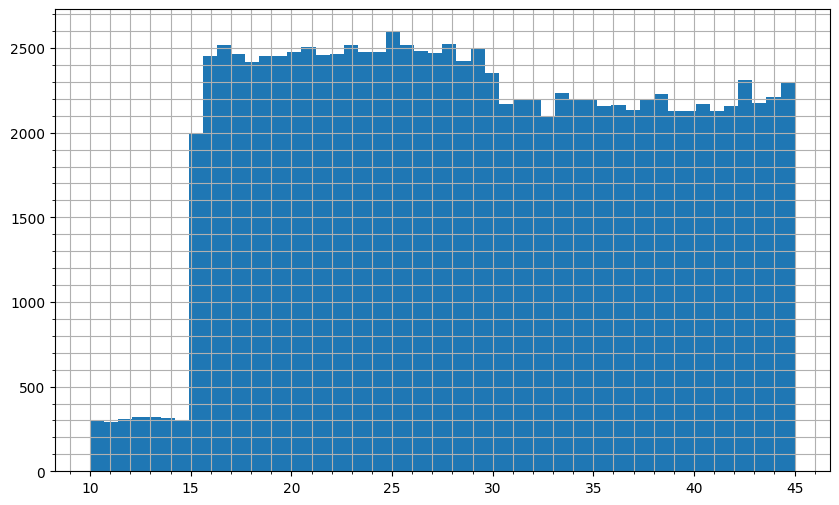

In [64]:
#distribution 
ax = data["avg_ctat"].hist(bins=50, figsize = (10,6))

ax.minorticks_on()
ax.grid(True, which="both")


Here there are also three distinct regions:

1. Region from 10 to 15 with low frequency observations, around 30
2. Region from 15 to 30 where the frequency reaches levels between 2400 and 2500
3. Region from 30 to 45 where the frequency slightly drops between 2100 and 2300

Right skewed with a clear concentration of values in the mid-to-high-range. No evident extreme outliers

In [65]:
col = "avg_ctat" 

q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr = q3 - q1

outliers = data[(data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)]

len(outliers), len(outliers) / len(data)


(0, 0.0)

### booking value

Total fare amount for the ride in dollars

In [66]:
# range? NaNs? distribution? the max is above 4k, do I have outliers? unique values? skewness and kurtosis? min-max sanity check?

In [67]:
print(f"Total unique values: {data['booking_value'].nunique()}")

Total unique values: 2566


In [68]:
print(f"Total NaNs: {data['booking_value'].isna().sum()}")

Total NaNs: 48000


In [69]:
data[data["booking_value"].isna()].head()


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,datetime,hour,weekday,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:37:50,1,0,False,0.258819,0.965926,10,CNR,1009222,10,CID,2030746
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:48:03,1,0,False,0.258819,0.965926,10,CNR,2740479,10,CID,3231181
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0,2024-01-01 01:49:56,1,0,False,0.258819,0.965926,10,CNR,7650148,10,CID,3381661
6,2024-01-01,02:14:50,CNR8839592,CID6577042,Bike,Jama Masjid,Sadar Bazar Gurgaon,11.8,NaN,NaN,NaN,NaN,1.0,2024-01-01 02:14:50,2,0,False,0.500000,0.866025,10,CNR,8839592,10,CID,6577042
7,2024-01-01,02:43:46,CNR4510033,CID3289424,eBike,Udyog Bhawan,Badarpur,NaN,NaN,NaN,NaN,NaN,1.0,2024-01-01 02:43:46,2,0,False,0.500000,0.866025,10,CNR,4510033,10,CID,3289424


The app offers you a final price before accepting the booking for cars. I would understand that there is no booking value for bikes or ebikes but others also have this field missing

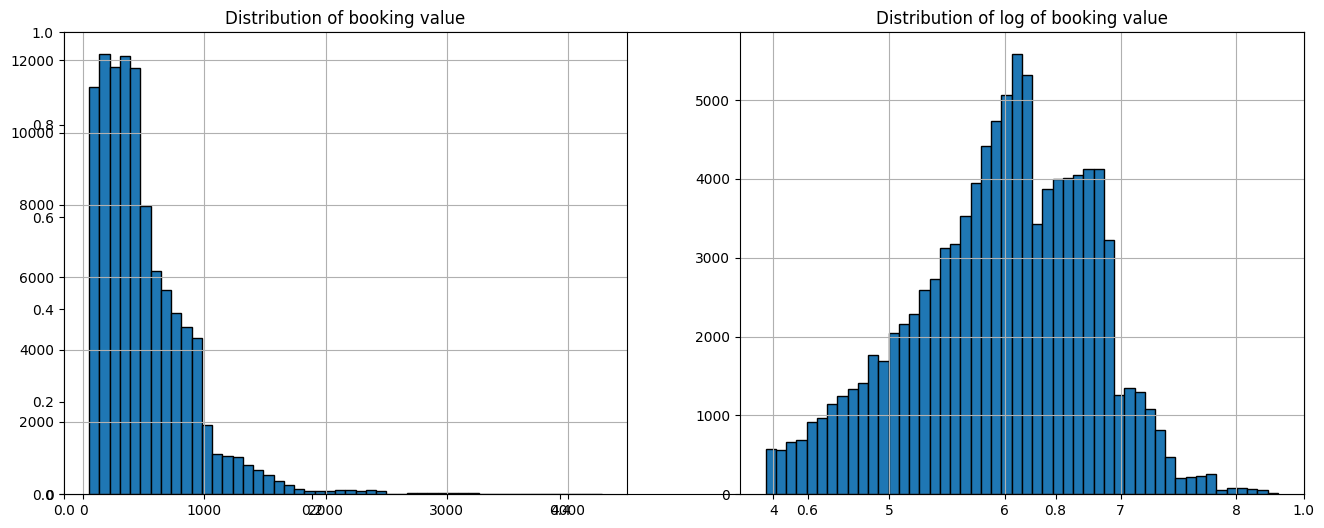

In [73]:
fig, ax = plt.subplots(figsize = (16, 6))
plt.subplot(1, 2, 1)
plt.hist(data['booking_value'], bins=50, edgecolor='black')
plt.title('Distribution of booking value');
plt.grid(True)
plt.subplot(1, 2, 2)
plt.hist(np.log1p(data['booking_value']), bins=50, edgecolor='black')
plt.title('Distribution of log of booking value')
plt.grid(True)

Left plot:
# todo describe the plots 


<Axes: >

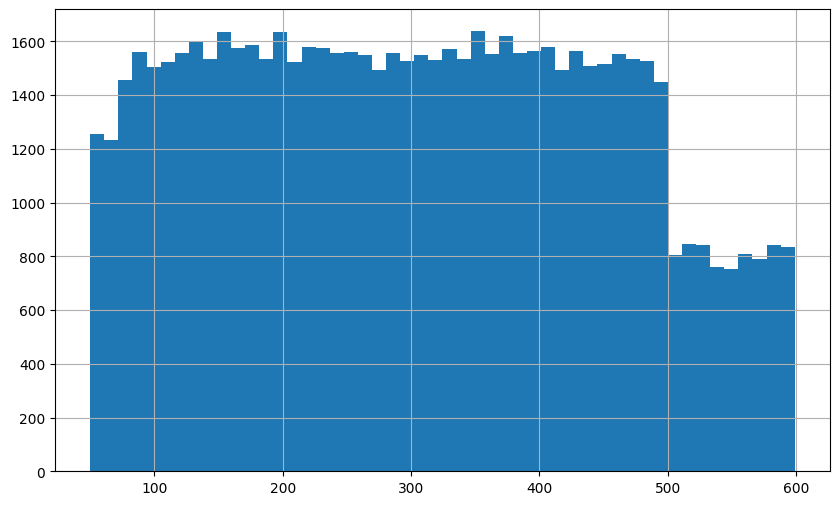

In [71]:
data[data["booking_value"] < 600]["booking_value"].hist(bins=50, figsize = (10,6))


In [72]:
# check correlation , boxplot, Q-Q plot and to decide if log transformation helps  with distribution, outliers and 